# Sen1Floods11 — Random Forest Flood Detection

Per-pixel binary flood classification on the [Sen1Floods11](https://github.com/cloudtostreet/Sen1Floods11) dataset, comparing three Random Forest models:

1. **SAR-only** — Sentinel-1 (VV, VH) + engineered features
2. **Optical-only** — Sentinel-2 (13 bands) + spectral indices (NDWI, MNDWI, NDVI, AWEI)
3. **Fused** — SAR + optical together

**GPU acceleration.** We try [RAPIDS cuML](https://docs.rapids.ai/api/cuml/stable/) for GPU-accelerated Random Forests. If cuML isn't available (or installation fails), we fall back to scikit-learn with `n_jobs=-1` to parallelize across all CPU cores. Feature engineering on large arrays is done with CuPy when a GPU is present.

**Labels.** QC mask values: `-1` = no data (masked out), `0` = not-water, `1` = water/flood. We train only on valid pixels.

**Runtime notes for Colab.** Set runtime to **T4 GPU** (`Runtime > Change runtime type > T4 GPU`). RAPIDS installs take ~3–5 minutes on first run; everything else runs in a few minutes with the default sampling settings.

## 1. Environment setup

Install geospatial deps and (optionally) RAPIDS cuML for GPU-accelerated RF. The cuML install is wrapped in a try/except so the notebook still runs end-to-end on CPU-only runtimes.

In [1]:
# Core geospatial + ML deps. rasterio reads the GeoTIFF chips.
!pip install -q rasterio scikit-learn matplotlib seaborn tqdm

In [2]:
# Detect whether we have a GPU. If we do, try to install RAPIDS cuML for
# GPU-accelerated Random Forests. If anything goes wrong, we silently fall
# back to scikit-learn later — the notebook still works, just on CPU.
import subprocess, sys

HAS_GPU = False
try:
    out = subprocess.check_output(['nvidia-smi', '-L'], stderr=subprocess.STDOUT).decode()
    HAS_GPU = 'GPU' in out
    print('GPU detected:')
    print(out)
except Exception:
    print('No GPU detected — will use scikit-learn on CPU.')

USE_CUML = False
if HAS_GPU:
    try:
        import cuml  # noqa: F401
        USE_CUML = True
        print('cuML already installed.')
    except ImportError:
        print('Installing RAPIDS cuML (this takes ~3–5 minutes on Colab)...')
        try:
            # Official Colab-friendly one-liner. Matches Colab's CUDA 12.x.
            !pip install -q --extra-index-url=https://pypi.nvidia.com \
                'cuml-cu12==25.4.*' 'cupy-cuda12x'
            import cuml  # noqa: F401
            import cupy  # noqa: F401
            USE_CUML = True
            print('cuML installed successfully.')
        except Exception as e:
            print(f'cuML install failed: {e}')
            print('Falling back to scikit-learn (parallelized across CPU cores).')
            USE_CUML = False

print(f'\nUSE_CUML = {USE_CUML}')

GPU detected:
GPU 0: Tesla T4 (UUID: GPU-f18928f4-7600-f737-e9cd-ae3e7ed15409)

cuML already installed.

USE_CUML = True


In [3]:
import os
import glob
import time
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    jaccard_score, confusion_matrix, classification_report
)

# Always import sklearn's RF as the fallback.
from sklearn.ensemble import RandomForestClassifier as SkRF

if USE_CUML:
    import cupy as cp
    from cuml.ensemble import RandomForestClassifier as CumlRF

np.random.seed(42)
sns.set_style('whitegrid')

## 2. Download the dataset

The full Sen1Floods11 bucket is ~14 GB. We download only the **HandLabeled** subset (the 446 expert-labeled chips) plus the train/val/test split CSVs — ~1.5 GB — which is what we need for supervised flood detection.

If `gsutil` is not authenticated, it still works for public buckets in anonymous mode.

In [4]:
DATA_ROOT = '/content/sen1floods11'
os.makedirs(DATA_ROOT, exist_ok=True)

# Hand-labeled data: S1Hand, S2Hand, LabelHand.
!mkdir -p {DATA_ROOT}/v1.1/data/flood_events/HandLabeled
!mkdir -p {DATA_ROOT}/v1.1/splits/flood_handlabeled

# Download. -m = multithreaded, -q = quiet. This takes a few minutes.
!gsutil -m -q cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/* \
    {DATA_ROOT}/v1.1/data/flood_events/HandLabeled/

!gsutil -m -q cp -r gs://sen1floods11/v1.1/splits/flood_handlabeled/* \
    {DATA_ROOT}/v1.1/splits/flood_handlabeled/

print('\nDownloaded directories:')
!ls {DATA_ROOT}/v1.1/data/flood_events/HandLabeled/
print('\nSplit files:')
!ls {DATA_ROOT}/v1.1/splits/flood_handlabeled/


Downloaded directories:
JRCWaterHand  LabelHand  S1Hand  S1OtsuLabelHand  S2Hand

Split files:
flood_bolivia_data.csv	flood_train_data.csv
flood_test_data.csv	flood_valid_data.csv


In [5]:
S1_DIR    = f'{DATA_ROOT}/v1.1/data/flood_events/HandLabeled/S1Hand'
S2_DIR    = f'{DATA_ROOT}/v1.1/data/flood_events/HandLabeled/S2Hand'
LABEL_DIR = f'{DATA_ROOT}/v1.1/data/flood_events/HandLabeled/LabelHand'
SPLIT_DIR = f'{DATA_ROOT}/v1.1/splits/flood_handlabeled'

def load_split(name):
    """Each split CSV has rows of the form: S1_filename,Label_filename.
    We return a list of chip IDs like 'Bolivia_103757'."""
    path = os.path.join(SPLIT_DIR, f'flood_{name}_data.csv')
    df = pd.read_csv(path, header=None, names=['s1', 'label'])
    # Derive chip id from the S1 filename: <Country>_<id>_S1Hand.tif
    chip_ids = df['s1'].str.replace('_S1Hand.tif', '', regex=False).tolist()
    return chip_ids

train_ids = load_split('train')
val_ids   = load_split('valid')
test_ids  = load_split('test')

print(f'Train chips: {len(train_ids)}')
print(f'Val chips:   {len(val_ids)}')
print(f'Test chips:  {len(test_ids)}')
print(f'Example id:  {train_ids[0]}')

Train chips: 252
Val chips:   89
Test chips:  90
Example id:  Ghana_103272


## 3. Load and featurize chips

Each chip is 512×512. Loading every pixel of every chip gives us ~117M training pixels, which is overkill for a Random Forest and will blow out RAM. We **subsample** each chip to keep class balance manageable and training fast.

### Feature engineering

- **SAR features (Sentinel-1):** VV, VH, VV−VH, VV/VH ratio, and the normalized polarization difference `(VV−VH)/(VV+VH)`. SAR backscatter over water is typically very low, so these contrasts matter.
- **Optical features (Sentinel-2):** all 13 bands plus spectral indices tuned for water:
  - **NDWI** = (Green − NIR) / (Green + NIR) — McFeeters, separates water from vegetation/soil
  - **MNDWI** = (Green − SWIR1) / (Green + SWIR1) — Xu, better over built-up areas
  - **NDVI** = (NIR − Red) / (NIR + Red) — helps distinguish vegetation
  - **AWEI_nsh** = 4·(Green − SWIR1) − (0.25·NIR + 2.75·SWIR2) — Feyisa

Index math is vectorized — on GPU with CuPy if available, otherwise NumPy.

In [6]:
# Sentinel-2 band indices (0-based, matches Sen1Floods11 band order)
S2_BLUE, S2_GREEN, S2_RED = 1, 2, 3
S2_NIR = 7
S2_SWIR1, S2_SWIR2 = 11, 12

EPS = 1e-7  # prevents divide-by-zero in ratios/indices

def _safe_div(a, b, xp):
    return a / (b + EPS)

def compute_sar_features(s1, xp=np):
    """s1 shape: (2, H, W). Returns (5, H, W) feature stack."""
    vv, vh = s1[0], s1[1]
    diff  = vv - vh
    ratio = _safe_div(vv, vh, xp)
    npd   = _safe_div(vv - vh, vv + vh, xp)  # normalized polarization difference
    return xp.stack([vv, vh, diff, ratio, npd], axis=0)

def compute_optical_features(s2, xp=np):
    """s2 shape: (13, H, W), scaled reflectance. Returns (13+4, H, W).
    We rescale reflectance by /10000 so indices are in their natural range."""
    s2f = s2.astype(xp.float32) / 10000.0
    green = s2f[S2_GREEN]
    red   = s2f[S2_RED]
    nir   = s2f[S2_NIR]
    swir1 = s2f[S2_SWIR1]
    swir2 = s2f[S2_SWIR2]

    ndwi  = _safe_div(green - nir,   green + nir,   xp)
    mndwi = _safe_div(green - swir1, green + swir1, xp)
    ndvi  = _safe_div(nir - red,     nir + red,     xp)
    awei  = 4.0 * (green - swir1) - (0.25 * nir + 2.75 * swir2)

    indices = xp.stack([ndwi, mndwi, ndvi, awei], axis=0)
    return xp.concatenate([s2f, indices], axis=0)

# Names — handy for feature importance plots later.
SAR_FEATURE_NAMES = ['VV', 'VH', 'VV-VH', 'VV/VH', 'NPD']
OPT_FEATURE_NAMES = [f'S2_B{i+1}' for i in range(13)] + ['NDWI', 'MNDWI', 'NDVI', 'AWEI']
FUSED_FEATURE_NAMES = SAR_FEATURE_NAMES + OPT_FEATURE_NAMES

In [7]:
def read_chip(chip_id):
    """Load S1, S2, and label for a chip. Returns (s1, s2, label) as NumPy arrays.
    s1: (2, H, W) float32 dB
    s2: (13, H, W) uint16 reflectance
    label: (H, W) int with values in {-1, 0, 1}"""
    s1_path    = os.path.join(S1_DIR,    f'{chip_id}_S1Hand.tif')
    s2_path    = os.path.join(S2_DIR,    f'{chip_id}_S2Hand.tif')
    label_path = os.path.join(LABEL_DIR, f'{chip_id}_LabelHand.tif')
    with rasterio.open(s1_path) as src:
        s1 = src.read().astype(np.float32)
    with rasterio.open(s2_path) as src:
        s2 = src.read()
    with rasterio.open(label_path) as src:
        label = src.read(1).astype(np.int16)
    return s1, s2, label

# Sanity check: peek at one chip.
s1, s2, lbl = read_chip(train_ids[0])
print(f'S1 shape: {s1.shape}, dtype: {s1.dtype}, range: [{s1.min():.2f}, {s1.max():.2f}]')
print(f'S2 shape: {s2.shape}, dtype: {s2.dtype}, range: [{s2.min()}, {s2.max()}]')
print(f'Label shape: {lbl.shape}, unique: {np.unique(lbl)}')
valid = lbl != -1
print(f'Valid pixels: {valid.sum()} / {valid.size}  |  Water fraction among valid: {(lbl[valid] == 1).mean():.3f}')

S1 shape: (2, 512, 512), dtype: float32, range: [-47.38, 8.59]
S2 shape: (13, 512, 512), dtype: int16, range: [44, 5658]
Label shape: (512, 512), unique: [-1  0  1]
Valid pixels: 259269 / 262144  |  Water fraction among valid: 0.006


In [8]:
# --- Sampling config ---
# Per-chip pixel sampling caps training set size. With 252 train chips and
# 4000 samples/chip we get ~1M training pixels — plenty for RF and fits
# easily in memory/GPU. Test uses every valid pixel (no subsampling).
TRAIN_SAMPLES_PER_CHIP = 4000
VAL_SAMPLES_PER_CHIP   = 4000

# If True, we try to 50/50 balance water vs. non-water when sampling training
# pixels. Flood classes are heavily imbalanced (water is rare), so this is on.
BALANCE_TRAIN_CLASSES = True

def sample_chip_pixels(s1, s2, label, n_samples, balance=False, rng=None):
    """Pull (n_samples, 5) SAR features, (n_samples, 17) optical features, and labels
    from a chip, skipping no-data pixels. Uses GPU (cupy) if available."""
    if rng is None:
        rng = np.random.default_rng()
    xp = cp if USE_CUML else np

    s1_x = xp.asarray(s1)
    s2_x = xp.asarray(s2)
    lbl_x = xp.asarray(label)

    sar_feats = compute_sar_features(s1_x, xp=xp)        # (5, H, W)
    opt_feats = compute_optical_features(s2_x, xp=xp)    # (17, H, W)

    # Move back to CPU for sampling + sklearn compatibility. (We redo it on
    # GPU later for cuML training; per-chip arrays are small, so round-tripping
    # here is cheap and keeps the sampling code simple.)
    if xp is not np:
        sar_feats = cp.asnumpy(sar_feats)
        opt_feats = cp.asnumpy(opt_feats)

    H, W = label.shape
    sar_flat = sar_feats.reshape(sar_feats.shape[0], -1).T  # (H*W, 5)
    opt_flat = opt_feats.reshape(opt_feats.shape[0], -1).T  # (H*W, 17)
    lbl_flat = label.reshape(-1)

    # Drop no-data pixels and any pixels with NaN/inf features (a few S2
    # chips have bad pixels from clouds/saturation).
    valid = (lbl_flat != -1)
    feats_finite = np.isfinite(sar_flat).all(axis=1) & np.isfinite(opt_flat).all(axis=1)
    valid = valid & feats_finite

    sar_v = sar_flat[valid]
    opt_v = opt_flat[valid]
    lbl_v = lbl_flat[valid]

    if len(lbl_v) == 0:
        return None

    if balance:
        water_idx    = np.where(lbl_v == 1)[0]
        nonwater_idx = np.where(lbl_v == 0)[0]
        per_class = n_samples // 2
        if len(water_idx) == 0 or len(nonwater_idx) == 0:
            # No water (or no non-water) here — just take a simple random sample.
            pick = rng.choice(len(lbl_v), size=min(n_samples, len(lbl_v)), replace=False)
        else:
            # Sample with replacement if a class is smaller than `per_class`.
            w  = rng.choice(water_idx,    size=min(per_class, len(water_idx)),    replace=False)
            nw = rng.choice(nonwater_idx, size=min(per_class, len(nonwater_idx)), replace=False)
            pick = np.concatenate([w, nw])
    else:
        pick = rng.choice(len(lbl_v), size=min(n_samples, len(lbl_v)), replace=False)

    return sar_v[pick], opt_v[pick], lbl_v[pick]


def build_dataset(chip_ids, n_per_chip, balance, desc):
    rng = np.random.default_rng(42)
    sar_all, opt_all, lbl_all = [], [], []
    for cid in tqdm(chip_ids, desc=desc):
        try:
            out = sample_chip_pixels(*read_chip(cid), n_per_chip, balance, rng)
        except Exception as e:
            print(f'skip {cid}: {e}')
            continue
        if out is None:
            continue
        s, o, l = out
        sar_all.append(s); opt_all.append(o); lbl_all.append(l)
    X_sar = np.vstack(sar_all).astype(np.float32)
    X_opt = np.vstack(opt_all).astype(np.float32)
    y     = np.concatenate(lbl_all).astype(np.int32)
    return X_sar, X_opt, y

In [9]:
print('Building training set...')
X_sar_train, X_opt_train, y_train = build_dataset(
    train_ids, TRAIN_SAMPLES_PER_CHIP, balance=BALANCE_TRAIN_CLASSES, desc='train')

print('\nBuilding validation set...')
X_sar_val, X_opt_val, y_val = build_dataset(
    val_ids, VAL_SAMPLES_PER_CHIP, balance=False, desc='val')

X_fused_train = np.hstack([X_sar_train, X_opt_train])
X_fused_val   = np.hstack([X_sar_val,   X_opt_val])

print(f'\nTrain:  SAR {X_sar_train.shape}  Opt {X_opt_train.shape}  Fused {X_fused_train.shape}')
print(f'Val:    SAR {X_sar_val.shape}  Opt {X_opt_val.shape}  Fused {X_fused_val.shape}')
print(f'Train class balance: water={np.mean(y_train==1):.3f}')
print(f'Val   class balance: water={np.mean(y_val==1):.3f}')

Building training set...


train:   0%|          | 0/252 [00:00<?, ?it/s]


Building validation set...


val:   0%|          | 0/89 [00:00<?, ?it/s]


Train:  SAR (935567, 5)  Opt (935567, 17)  Fused (935567, 22)
Val:    SAR (344000, 5)  Opt (344000, 17)  Fused (344000, 22)
Train class balance: water=0.397
Val   class balance: water=0.114


## 4. Train three Random Forests

Same hyperparameters for all three so the comparison is about features, not tuning. On GPU we use `cuml.ensemble.RandomForestClassifier`; on CPU we fall back to sklearn with `n_jobs=-1`.

In [10]:
RF_PARAMS = dict(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
)

def make_rf():
    if USE_CUML:
        # cuML's RF has slightly different parameter names and uses its own
        # memory layout. `n_streams` parallelizes tree building across CUDA streams.
        return CumlRF(
            n_estimators=RF_PARAMS['n_estimators'],
            max_depth=RF_PARAMS['max_depth'],
            min_samples_leaf=RF_PARAMS['min_samples_leaf'],
            random_state=RF_PARAMS['random_state'],
            n_streams=4,
        )
    else:
        return SkRF(**RF_PARAMS, n_jobs=-1)

def fit_rf(model, X, y):
    # cuML prefers float32 arrays and int32 labels; sklearn is fine with either.
    X = X.astype(np.float32)
    y = y.astype(np.int32)
    if USE_CUML:
        # Move to GPU memory explicitly.
        X = cp.asarray(X); y = cp.asarray(y)
    t0 = time.time()
    model.fit(X, y)
    return model, time.time() - t0

def predict_rf(model, X, chunk_size=200_000):
    """Robust prediction that handles empty inputs and chunks large batches
    to avoid cuML FIL's 'invalid configuration argument' errors."""
    X = np.ascontiguousarray(X, dtype=np.float32)
    n = X.shape[0]
    if n == 0:
        return np.empty((0,), dtype=np.int32)

    if USE_CUML:
        # Chunk to keep FIL happy. 200k rows × ~22 float32 cols ≈ 17 MB per batch.
        out = np.empty(n, dtype=np.int32)
        for i in range(0, n, chunk_size):
            batch = X[i:i+chunk_size]
            X_gpu = cp.asarray(batch)
            pred = model.predict(X_gpu)
            if hasattr(pred, 'get'):
                pred = pred.get()
            out[i:i+chunk_size] = np.asarray(pred).astype(np.int32)
        return out
    return model.predict(X).astype(np.int32)

In [11]:
print(f'Using {"cuML (GPU)" if USE_CUML else "scikit-learn (CPU, n_jobs=-1)"}\n')

print('Training SAR-only RF...')
rf_sar, t_sar = fit_rf(make_rf(), X_sar_train, y_train)
print(f'  done in {t_sar:.1f}s')

print('Training Optical-only RF...')
rf_opt, t_opt = fit_rf(make_rf(), X_opt_train, y_train)
print(f'  done in {t_opt:.1f}s')

print('Training Fused (SAR + Optical) RF...')
rf_fused, t_fused = fit_rf(make_rf(), X_fused_train, y_train)
print(f'  done in {t_fused:.1f}s')

Using cuML (GPU)

Training SAR-only RF...
  done in 13.3s
Training Optical-only RF...
  done in 12.6s
Training Fused (SAR + Optical) RF...
  done in 11.8s


In [12]:
import pickle, os
os.makedirs('/content/drive/MyDrive/sen1floods11_models', exist_ok=True)
# Mount Drive first if you haven't:
# from google.colab import drive; drive.mount('/content/drive')

for name, m in [('rf_sar', rf_sar), ('rf_opt', rf_opt), ('rf_fused', rf_fused)]:
    with open(f'/content/drive/MyDrive/sen1floods11_models/{name}.pkl', 'wb') as f:
        pickle.dump(m, f)
    print(f'saved {name}')

saved rf_sar
saved rf_opt
saved rf_fused


## 5. Evaluate on the held-out test set

For the final test we evaluate on **every valid pixel** of every test chip — not a subsample — so the numbers reflect real deployment performance. We report:

- **Accuracy** — straightforward, but misleading under class imbalance.
- **Precision / Recall / F1** for the water class — what you actually care about in flood detection.
- **IoU (Jaccard)** — the standard segmentation metric, matches what the Sen1Floods11 paper reports.

In [13]:
def evaluate_streaming(model, feature_type, chip_ids, desc='test'):
    all_y, all_pred = [], []
    t0 = time.time()
    skipped = 0
    for cid in tqdm(chip_ids, desc=desc):
        try:
            s1, s2, label = read_chip(cid)
        except Exception as e:
            print(f'skip {cid}: {e}'); continue

        xp = cp if USE_CUML else np
        sar_feats = compute_sar_features(xp.asarray(s1), xp=xp)
        opt_feats = compute_optical_features(xp.asarray(s2), xp=xp)
        if xp is not np:
            sar_feats = cp.asnumpy(sar_feats); opt_feats = cp.asnumpy(opt_feats)

        sar_flat = sar_feats.reshape(sar_feats.shape[0], -1).T
        opt_flat = opt_feats.reshape(opt_feats.shape[0], -1).T
        lbl_flat = label.reshape(-1)
        valid = (lbl_flat != -1) & np.isfinite(sar_flat).all(axis=1) & np.isfinite(opt_flat).all(axis=1)

        # Skip chips with no valid pixels — this is the fix for the FIL crash.
        if valid.sum() == 0:
            skipped += 1
            del s1, s2, label, sar_feats, opt_feats, sar_flat, opt_flat
            continue

        if feature_type == 'sar':   X = sar_flat[valid]
        elif feature_type == 'opt': X = opt_flat[valid]
        else:                       X = np.hstack([sar_flat[valid], opt_flat[valid]])

        y = lbl_flat[valid]
        pred = predict_rf(model, X)
        all_y.append(y); all_pred.append(pred)

        del s1, s2, label, sar_feats, opt_feats, sar_flat, opt_flat, X

    if skipped:
        print(f'  skipped {skipped} chip(s) with no valid pixels')

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    infer_s = time.time() - t0
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall':    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1':        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'iou_water': jaccard_score(y_true, y_pred, pos_label=1, zero_division=0),
        'infer_s':   infer_s,
        'y_true':    y_true,
        'y_pred':    y_pred,
    }


import gc
r_sar   = evaluate_streaming(rf_sar,   'sar',   test_ids, 'sar')
gc.collect()
r_opt   = evaluate_streaming(rf_opt,   'opt',   test_ids, 'opt')
gc.collect()
r_fused = evaluate_streaming(rf_fused, 'fused', test_ids, 'fused')
gc.collect()

sar:   0%|          | 0/90 [00:00<?, ?it/s]

  skipped 2 chip(s) with no valid pixels


opt:   0%|          | 0/90 [00:00<?, ?it/s]

  skipped 2 chip(s) with no valid pixels


fused:   0%|          | 0/90 [00:00<?, ?it/s]

  skipped 2 chip(s) with no valid pixels


19

In [14]:
def evaluate(name, model, X, y, train_time):
    t0 = time.time()
    y_pred = predict_rf(model, X)
    infer_time = time.time() - t0
    return {
        'model': name,
        'accuracy':  accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, pos_label=1, zero_division=0),
        'recall':    recall_score(y, y_pred, pos_label=1, zero_division=0),
        'f1':        f1_score(y, y_pred, pos_label=1, zero_division=0),
        'iou_water': jaccard_score(y, y_pred, pos_label=1, zero_division=0),
        'train_s':   train_time,
        'infer_s':   infer_time,
        'y_pred':    y_pred,
    }

# After running the three evaluate_streaming() calls, you already have r_sar/r_opt/r_fused.
# Build the same results structure the rest of the notebook expects:

results = [
    {'model': 'SAR only',      **r_sar,   'train_s': t_sar},
    {'model': 'Optical only',  **r_opt,   'train_s': t_opt},
    {'model': 'SAR + Optical', **r_fused, 'train_s': t_fused},
]

# For downstream cells that expect 'y_pred' key (confusion matrices in section 6):
# r_sar already has 'y_pred' and 'y_true' from evaluate_streaming.

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('y_pred', 'y_true')}
    for r in results
]).set_index('model')

print('\n===== Test-set results =====')
print(results_df.round(4).to_string())

# The y_test used by section 6's confusion matrices needs to come from one of the
# streaming results (they all have the same y_true since all three models were
# evaluated on the same chips):
y_test = r_sar['y_true']



===== Test-set results =====
               accuracy  precision  recall      f1  iou_water  infer_s  train_s
model                                                                          
SAR only         0.8860     0.5238  0.8044  0.6344     0.4646  18.7137  13.3263
Optical only     0.9771     0.8708  0.9560  0.9114     0.8373   9.5755  12.6183
SAR + Optical    0.9777     0.8730  0.9584  0.9137     0.8411  11.5671  11.8031


## 6. Compare the three models

Headline bar chart, per-model confusion matrices, and per-model feature importances.

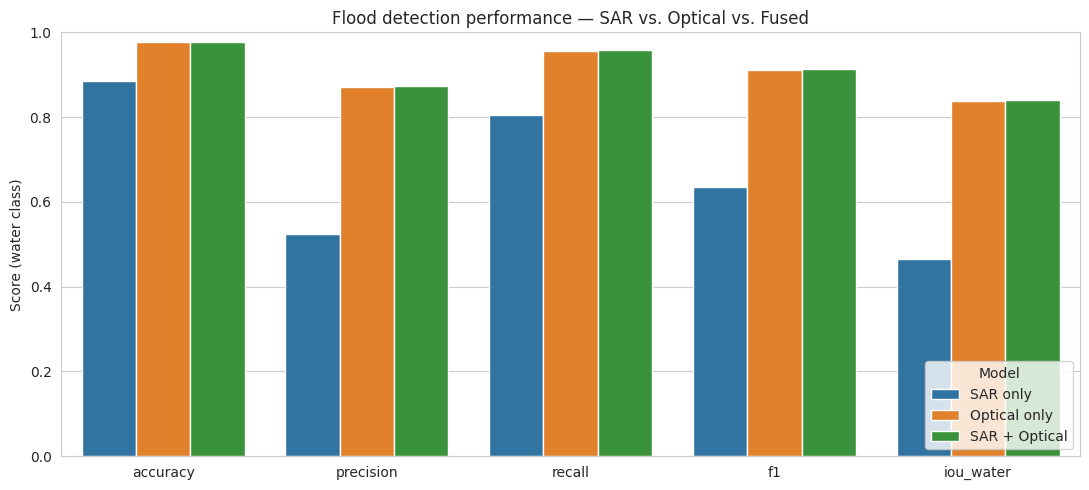

In [15]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'iou_water']
plot_df = results_df[metrics_to_plot].reset_index().melt(
    id_vars='model', var_name='metric', value_name='score')

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x='metric', y='score', hue='model')
plt.title('Flood detection performance — SAR vs. Optical vs. Fused')
plt.ylim(0, 1)
plt.ylabel('Score (water class)')
plt.xlabel('')
plt.legend(title='Model', loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['y_pred'], labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No water', 'Water'], yticklabels=['No water', 'Water'], ax=ax)
    ax.set_title(f"{r['model']}  |  IoU={r['iou_water']:.3f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
fig.suptitle('Confusion matrices (row-normalized; counts in cells)', y=1.02)
plt.tight_layout()
plt.show()

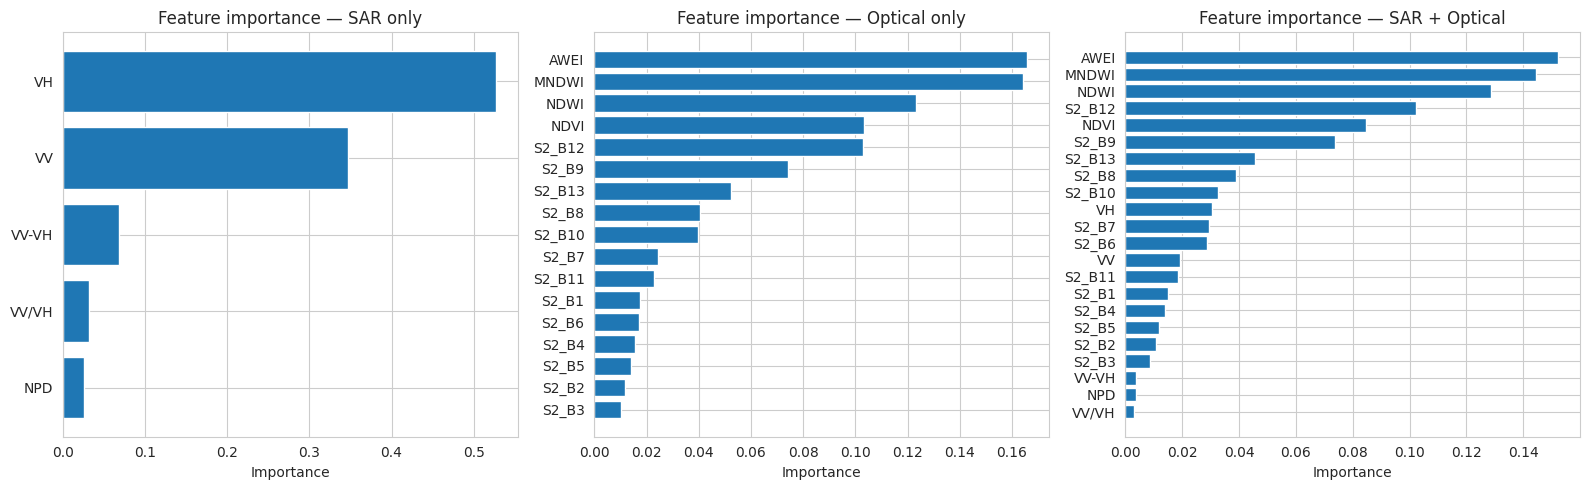

In [16]:
def feature_importances(model):
    # cuML exposes the same attribute as sklearn for classifiers; if not,
    # we return None and skip the plot gracefully.
    try:
        imp = model.feature_importances_
        if hasattr(imp, 'get'):
            imp = imp.get()
        return np.asarray(imp)
    except Exception:
        return None

fi_sets = [
    ('SAR only',      feature_importances(rf_sar),   SAR_FEATURE_NAMES),
    ('Optical only',  feature_importances(rf_opt),   OPT_FEATURE_NAMES),
    ('SAR + Optical', feature_importances(rf_fused), FUSED_FEATURE_NAMES),
]

if all(fi is not None for _, fi, _ in fi_sets):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (name, fi, feats) in zip(axes, fi_sets):
        order = np.argsort(fi)[::-1]
        ax.barh([feats[i] for i in order][::-1], fi[order][::-1])
        ax.set_title(f'Feature importance — {name}')
        ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importances unavailable from this backend — skipping plot.')

## 7. Qualitative inspection

Pick a few test chips and visualize prediction vs. ground truth for each model. This is often more informative than aggregate metrics for flood mapping — failure modes (missed channels, false positives over wet soil, SAR speckle) tend to be spatial.

In [17]:
def predict_full_chip(chip_id, model, feature_type):
    s1, s2, label = read_chip(chip_id)
    xp = cp if USE_CUML else np
    sar_feats = compute_sar_features(xp.asarray(s1), xp=xp)
    opt_feats = compute_optical_features(xp.asarray(s2), xp=xp)
    if xp is not np:
        sar_feats = cp.asnumpy(sar_feats)
        opt_feats = cp.asnumpy(opt_feats)
    H, W = label.shape
    if feature_type == 'sar':
        X = sar_feats.reshape(sar_feats.shape[0], -1).T
    elif feature_type == 'opt':
        X = opt_feats.reshape(opt_feats.shape[0], -1).T
    else:
        X = np.vstack([sar_feats.reshape(sar_feats.shape[0], -1),
                       opt_feats.reshape(opt_feats.shape[0], -1)]).T
    # Handle any non-finite pixels so prediction doesn't error.
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    y_pred = predict_rf(model, X).reshape(H, W)
    # Mask out no-data regions for display.
    y_pred_masked = np.where(label == -1, -1, y_pred)
    return s1, s2, label, y_pred_masked

def show_rgb(s2):
    # True-color-ish (R, G, B = B4, B3, B2). Stretch to 2nd/98th percentile.
    rgb = s2[[S2_RED, S2_GREEN, S2_BLUE]].astype(np.float32).transpose(1, 2, 0) / 10000.0
    lo, hi = np.nanpercentile(rgb, [2, 98])
    rgb = np.clip((rgb - lo) / (hi - lo + EPS), 0, 1)
    return rgb

def show_sar(s1):
    # Log-ish stretch of VV for display.
    vv = s1[0]
    lo, hi = np.nanpercentile(vv, [2, 98])
    return np.clip((vv - lo) / (hi - lo + EPS), 0, 1)

# Pick a handful of test chips — prefer ones with substantial water.
sample_ids = []
for cid in test_ids[:30]:
    _, _, lbl = read_chip(cid)
    valid = lbl != -1
    if valid.sum() > 0 and (lbl[valid] == 1).mean() > 0.05:
        sample_ids.append(cid)
    if len(sample_ids) == 3:
        break
print('Visualizing chips:', sample_ids)

Visualizing chips: ['Ghana_313799', 'Ghana_319168', 'Ghana_866994']


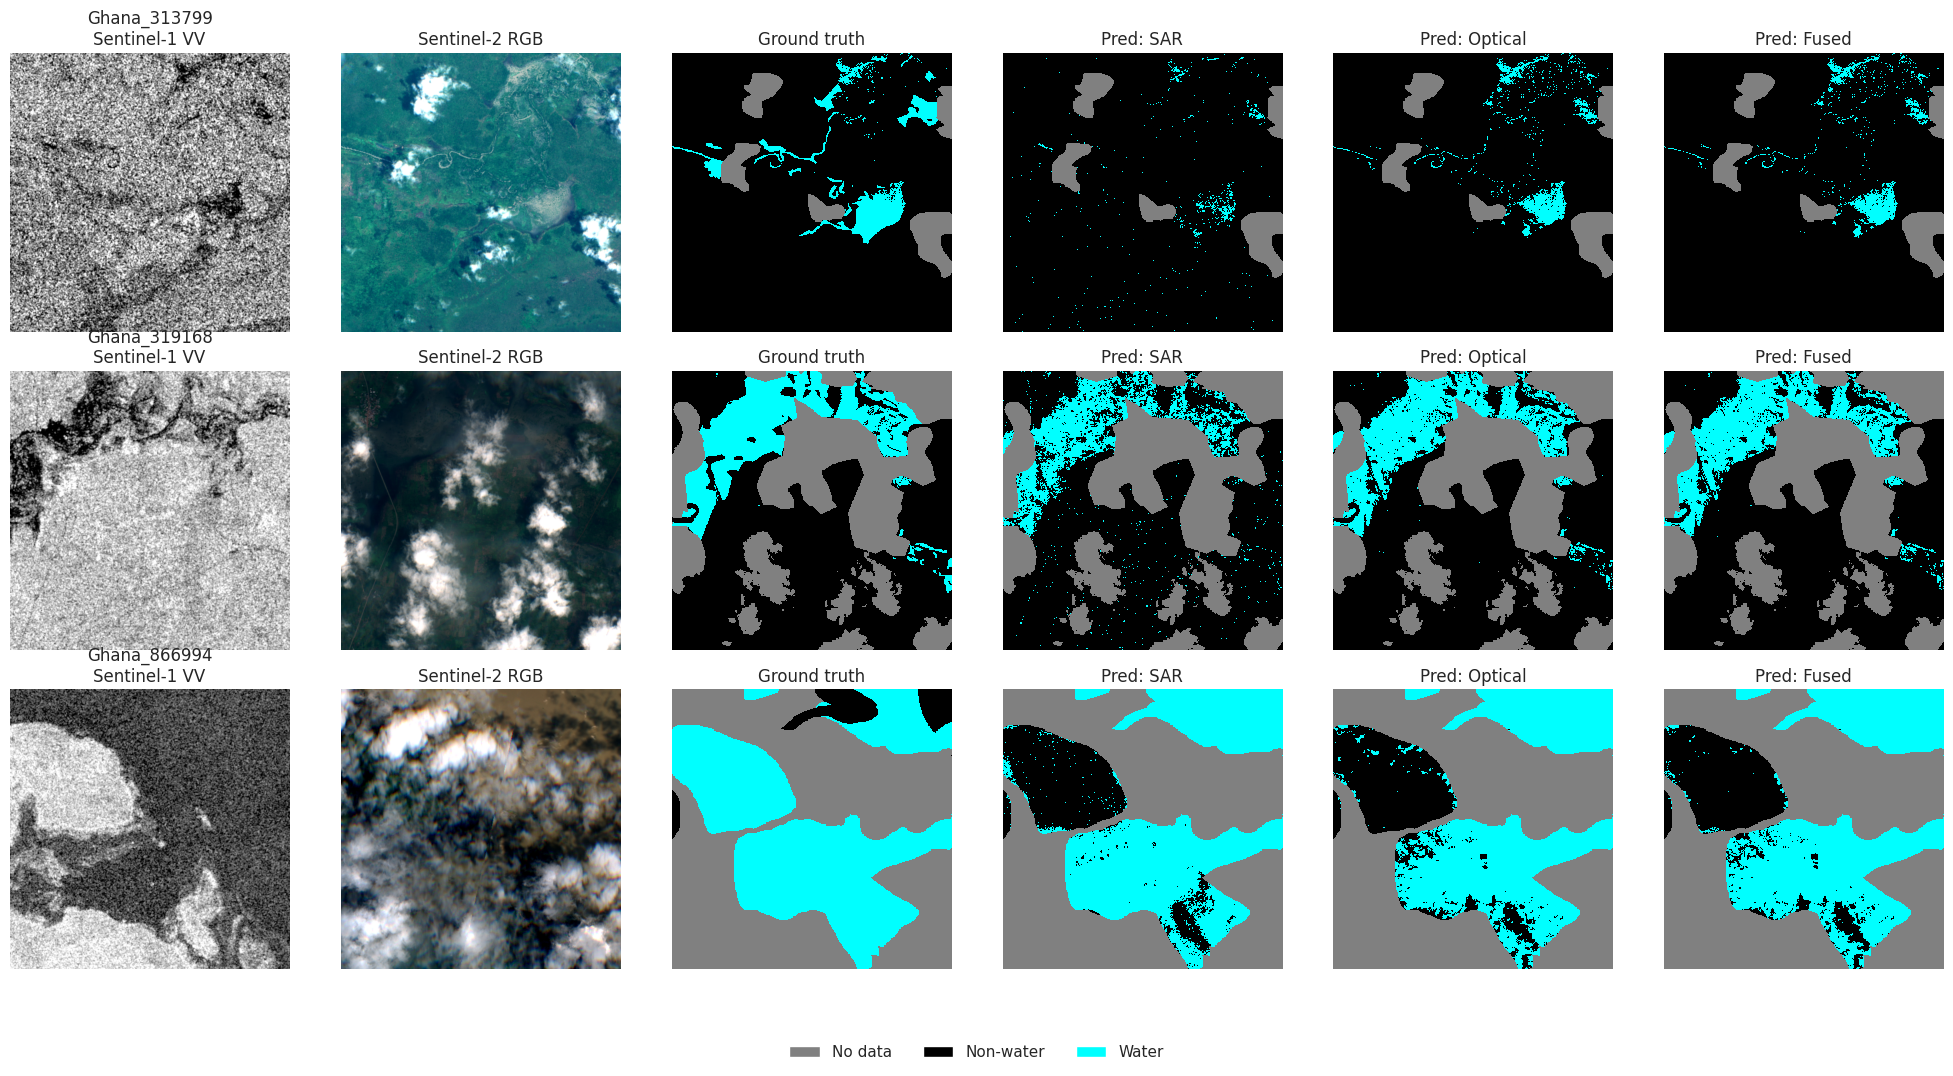

In [18]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Discrete 3-class colormap: no-data (-1) = gray, non-water (0) = black, water (1) = cyan.
class_cmap = ListedColormap(['#808080', '#000000', '#00FFFF'])
class_norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], class_cmap.N)
cmap_args = dict(cmap=class_cmap, norm=class_norm, interpolation='nearest')

legend_handles = [
    Patch(facecolor='#808080', edgecolor='white', label='No data'),
    Patch(facecolor='#000000', edgecolor='white', label='Non-water'),
    Patch(facecolor='#00FFFF', edgecolor='white', label='Water'),
]

n = len(sample_ids)
fig, axes = plt.subplots(n, 6, figsize=(20, 3.5 * n))
if n == 1:
    axes = axes[None, :]

for row, cid in enumerate(sample_ids):
    s1, s2, label, pred_sar   = predict_full_chip(cid, rf_sar,   'sar')
    _,  _,  _,     pred_opt   = predict_full_chip(cid, rf_opt,   'opt')
    _,  _,  _,     pred_fused = predict_full_chip(cid, rf_fused, 'fused')

    axes[row, 0].imshow(show_sar(s1), cmap='gray'); axes[row, 0].set_title(f'{cid}\nSentinel-1 VV')
    axes[row, 1].imshow(show_rgb(s2));              axes[row, 1].set_title('Sentinel-2 RGB')
    axes[row, 2].imshow(label,      **cmap_args);   axes[row, 2].set_title('Ground truth')
    axes[row, 3].imshow(pred_sar,   **cmap_args);   axes[row, 3].set_title('Pred: SAR')
    axes[row, 4].imshow(pred_opt,   **cmap_args);   axes[row, 4].set_title('Pred: Optical')
    axes[row, 5].imshow(pred_fused, **cmap_args);   axes[row, 5].set_title('Pred: Fused')
    for ax in axes[row]:
        ax.axis('off')

# One legend for the whole figure, placed below the grid.
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
    fontsize=11,
)

plt.tight_layout()
# Leave a bit of room at the bottom for the legend.
plt.subplots_adjust(bottom=0.08 if n > 1 else 0.15)
plt.show()

# Apply RF Model to Nairobi 2024 Floods

In [ ]:
!pip install -q pystac-client odc-stac planetary-computer rioxarray \
                dask[complete] scipy

In [ ]:
import numpy as np
import xarray as xr
import dask.array as da
dask.config.set(scheduler='threads', num_workers=2)  # or even 1
import rioxarray  # noqa: F401 — registers the .rio accessor
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy import ndimage

import pystac_client
import planetary_computer as pc
import odc.stac

# --- Configuration ---
# Nairobi AOI
LATMIN, LATMAX = -1.5371, -1.0918
LONMIN, LONMAX =  36.5134, 37.2744
BBOX = [LONMIN, LATMIN, LONMAX, LATMAX]

# Locked time windows (group project constraint)
BEFORE_SLICE = slice('2024-03-06', '2024-04-06')
AFTER_SLICE  = slice('2024-05-01', '2024-06-01')
QUERY_START = '2024-03-06'
QUERY_END   = '2024-06-01'

# Working grid — 10 m, UTM 37S (EPSG:32737 covers Nairobi)
TARGET_CRS = 'EPSG:32737'
TARGET_RES = 10  # metres

# Band names — must match what we trained on.
SAR_BAND_NAMES = ['vv', 'vh']
# Sen1Floods11 used 13 S2 bands in order B1..B12 with B8A between B8 and B9.
# Planetary Computer's sentinel-2-l2a names them B01..B12 plus B8A.
# Note: L2A does NOT include B10 (cirrus) — we fill it with zeros below.
S2_L2A_BANDS = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
                'B08', 'B8A', 'B09', 'B11', 'B12']
# Full training order (what the model expects):
FULL_S2_ORDER = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
                 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12']

TILE = 512  # Dask chunk size (matches training chip size, RAM-friendly)

# If running sklearn (CPU), tell each tree-ensemble not to spawn threads
# inside each Dask tile — Dask is already parallelizing across tiles.
try:
    _use_cuml = USE_CUML
except NameError:
    _use_cuml = False
if not _use_cuml:
    try:
        rf_fused.n_jobs = 1
    except Exception:
        pass

print(f'AOI bbox:   {BBOX}')
print(f'Target CRS: {TARGET_CRS} @ {TARGET_RES}m')

In [ ]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace,
)

# --- Sentinel-1 RTC ---
s1_search = catalog.search(
    collections=['sentinel-1-rtc'],
    bbox=BBOX,
    datetime=f'{QUERY_START}/{QUERY_END}',
)
s1_items = list(s1_search.items())
print(f'Sentinel-1 RTC scenes found: {len(s1_items)}')

# --- Sentinel-2 L2A ---
# Generous cloud filter (<70%) because long rains are cloudy and we need
# enough scenes for the median composite. The per-pixel SCL mask would be
# better but adds complexity — median-over-time already handles most clouds.
s2_search = catalog.search(
    collections=['sentinel-2-l2a'],
    bbox=BBOX,
    datetime=f'{QUERY_START}/{QUERY_END}',
    query={'eo:cloud_cover': {'lt': 70}},
)
s2_items = list(s2_search.items())
print(f'Sentinel-2 L2A scenes found (<70% cloud): {len(s2_items)}')

In [ ]:
# Load both collections onto the SAME grid (same CRS, resolution, bbox, chunks).
# odc-stac handles reprojection and resampling lazily via Dask.
common_load_kwargs = dict(
    bbox=BBOX,
    crs=TARGET_CRS,
    resolution=TARGET_RES,
    chunks={'x': TILE, 'y': TILE},
)

s1_ds = odc.stac.load(
    s1_items,
    bands=SAR_BAND_NAMES,
    **common_load_kwargs,
)

s2_ds = odc.stac.load(
    s2_items,
    bands=S2_L2A_BANDS,
    **common_load_kwargs,
)

# Sentinel-1 RTC from Planetary Computer is in linear power units, not dB.
# Sen1Floods11 trained on dB, so we convert. Clamp tiny values to avoid log(0).
for b in SAR_BAND_NAMES:
    s1_ds[b] = 10.0 * np.log10(s1_ds[b].where(s1_ds[b] > 1e-6, 1e-6))

# Backfill B10 with zeros. Sen1Floods11's S2 was L1C which has B10 (cirrus),
# but L2A removes it. Zeros is the least-bad stand-in — it only affects the
# raw-band contribution to the feature vector, not NDWI/MNDWI/NDVI/AWEI
# (none of which use B10).
s2_ds['B10'] = xr.zeros_like(s2_ds['B01'])

print(f'S1 cube: time={s1_ds.sizes["time"]}  y={s1_ds.sizes["y"]}  x={s1_ds.sizes["x"]}  vars={list(s1_ds.data_vars)}')
print(f'S2 cube: time={s2_ds.sizes["time"]}  y={s2_ds.sizes["y"]}  x={s2_ds.sizes["x"]}  vars={list(s2_ds.data_vars)}')
assert s1_ds.sizes['y'] == s2_ds.sizes['y'] and s1_ds.sizes['x'] == s2_ds.sizes['x'], \
    'S1 and S2 must share the same spatial grid — check load kwargs'

In [ ]:
# Slice into before/after windows. S1 and S2 time axes are independent.
s1_before = s1_ds.sel(time=BEFORE_SLICE)
s1_after  = s1_ds.sel(time=AFTER_SLICE)
s2_before = s2_ds.sel(time=BEFORE_SLICE)
s2_after  = s2_ds.sel(time=AFTER_SLICE)

def _dates(ds): return [str(t)[:10] for t in ds.time.values]

print('=== BEFORE window (Mar 6 – Apr 6) ===')
print(f'  S1: {s1_before.sizes["time"]:2d} scenes  {_dates(s1_before)}')
print(f'  S2: {s2_before.sizes["time"]:2d} scenes  {_dates(s2_before)}')
print()
print('=== AFTER window (May 1 – Jun 1) ===')
print(f'  S1: {s1_after.sizes["time"]:2d} scenes  {_dates(s1_after)}')
print(f'  S2: {s2_after.sizes["time"]:2d} scenes  {_dates(s2_after)}')

for name, ds in [('S1 before', s1_before), ('S1 after', s1_after),
                 ('S2 before', s2_before), ('S2 after', s2_after)]:
    if ds.sizes['time'] == 0:
        print(f'\n⚠️  {name} has 0 scenes — expand the window or relax cloud filter.')

In [ ]:
def predict_water_tile(s1_block, s2_block, model_ref):
    """Runs on one Dask tile. Inputs: (2, h, w) float32 dB, (13, h, w) uint16.
    Returns: (h, w) uint8 water mask."""
    _, H, W = s1_block.shape

    sar = compute_sar_features(s1_block.astype(np.float32), xp=np)    # (5, H, W)
    opt = compute_optical_features(s2_block.astype(np.uint16), xp=np) # (17, H, W)
    stacked = np.concatenate([sar, opt], axis=0)                      # (22, H, W)
    X = stacked.reshape(stacked.shape[0], -1).T.astype(np.float32)

    # Nodata / non-finite rows: zero them so cuML FIL doesn't choke, then predict 0.
    bad = ~np.isfinite(X).all(axis=1)
    X[bad] = 0.0
    pred = predict_rf(model_ref, X)
    pred[bad] = 0
    return pred.reshape(H, W).astype(np.uint8)


def ds_to_stacked_dask(ds, band_names, tile=TILE):
    """Stack named bands along a new leading axis → dask array (C, H, W)."""
    arr = ds[band_names].to_array(dim='band').data  # dask (C, H, W)
    C = arr.shape[0]
    return arr.rechunk((C, tile, tile))


def water_mask(s1_2d, s2_2d, model):
    """Given 2D (composited or single-timestep) s1/s2 Datasets,
    return a lazy dask array of shape (H, W) with the predicted water mask."""
    s1 = ds_to_stacked_dask(s1_2d, SAR_BAND_NAMES)     # (2, H, W)
    s2 = ds_to_stacked_dask(s2_2d, FULL_S2_ORDER)      # (13, H, W)
    return da.map_blocks(
        predict_water_tile,
        s1, s2, model,
        drop_axis=0,
        dtype=np.uint8,
        chunks=(s1.chunks[1], s1.chunks[2]),
    )

In [ ]:
def median_over_time(ds):
    """Median composite across time, skipping NaN."""
    return ds.median(dim='time', skipna=True)

def any_water_composite(s1_window, s2_window, model):
    """Predict per-S1-scene water mask (with S2 median as stable optical context),
    then OR across time. Anchoring on S1 because SAR penetrates cloud and is the
    reliable temporal signal during the rainy season."""
    s2_median = median_over_time(s2_window)
    masks = []
    for t in range(s1_window.sizes['time']):
        s1_t = s1_window.isel(time=t)
        masks.append(water_mask(s1_t, s2_median, model))
    if not masks:
        return None
    if len(masks) == 1:
        return masks[0]
    return da.stack(masks, axis=0).max(axis=0).astype(np.uint8)

print('Building lazy Dask graph...')

water_before_med = water_mask(median_over_time(s1_before),
                              median_over_time(s2_before), rf_fused)
water_after_med  = water_mask(median_over_time(s1_after),
                              median_over_time(s2_after),  rf_fused)

water_before_any = any_water_composite(s1_before, s2_before, rf_fused)
water_after_any  = any_water_composite(s1_after,  s2_after,  rf_fused)

flood_conservative_lazy = ((water_after_med == 1) & (water_before_med == 0)).astype(np.uint8)
flood_sensitive_lazy    = ((water_after_any == 1) & (water_before_any == 0)).astype(np.uint8)

print(f'  water_before_med: {water_before_med.shape}, chunks={water_before_med.chunksize}')
print(f'  flood_conservative_lazy: {flood_conservative_lazy.shape}')

In [ ]:
print('Computing water masks and flood maps (parallel tiles)...')

with ProgressBar():
    wb_med, wa_med, flood_c = da.compute(
        water_before_med, water_after_med, flood_conservative_lazy,
    )
print(f'Conservative done. flood_c pixels: {int(flood_c.sum()):,}')
del water_before_med, water_after_med, flood_conservative_lazy
gc.collect()

with ProgressBar():
    wb_any, wa_any, flood_s = da.compute(
        water_before_any, water_after_any, flood_sensitive_lazy,
    )
print(f'Sensitive done. flood_s pixels: {int(flood_s.sum()):,}')
del water_before_any, water_after_any, flood_sensitive_lazy
gc.collect()

In [ ]:
H, W = flood_c.shape
px_area_ha = (TARGET_RES ** 2) / 10_000  # 10 m pixel = 0.01 ha

print(f'\nAOI: {H} x {W} = {H*W:,} pixels (~{H*W*px_area_ha:.0f} ha)')
print()
print(f'{"Layer":<26}  {"pixels":>12}  {"% AOI":>8}  {"ha":>10}')
for name, arr in [('Water before (median)', wb_med),
                  ('Water after  (median)', wa_med),
                  ('Water before (any)   ', wb_any),
                  ('Water after  (any)   ', wa_any),
                  ('FLOOD — conservative ', flood_c),
                  ('FLOOD — sensitive    ', flood_s)]:
    n = int(arr.sum())
    print(f'{name:<26}  {n:>12,}  {n/(H*W)*100:>7.2f}%  {n*px_area_ha:>9.1f}')